<a href="https://colab.research.google.com/github/truth-breaker/DATA-SCIENCE/blob/main/Linear_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [46]:
market = pd.read_csv("marketing_sales_data.csv")

In [47]:
market

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377
...,...,...,...,...,...
567,Medium,14.656633,3.817980,Micro,191.521266
568,High,28.110171,7.358169,Mega,297.626731
569,Medium,11.401084,5.818697,Nano,145.416851
570,Medium,21.119991,5.703028,Macro,209.326830


In [48]:
market.shape

(572, 5)

In [49]:
market.isna().sum()

,0
TV,0
Radio,0
Social Media,0
Influencer,0
Sales,0


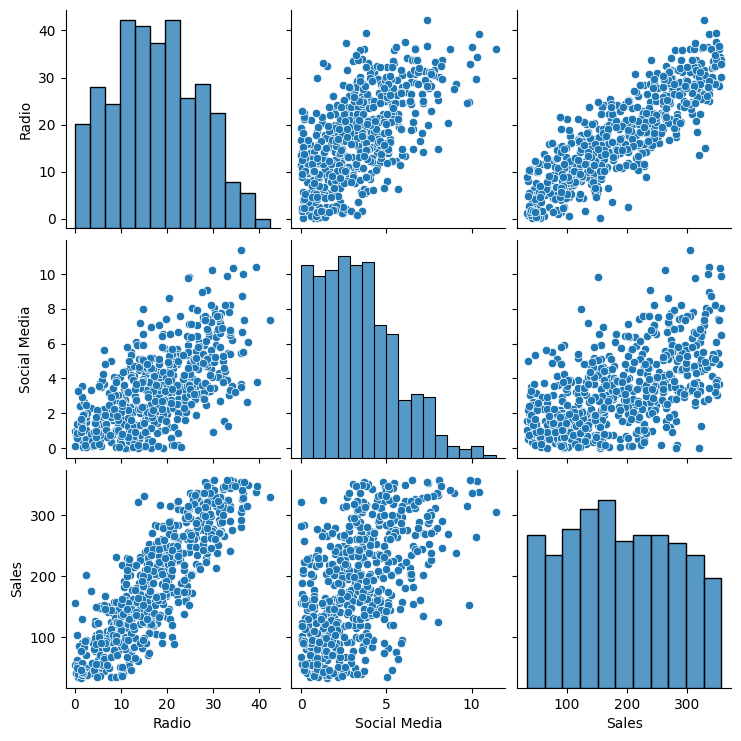

In [50]:
sns.pairplot(market)
plt.show()

In [51]:
train = market.sample(frac =.75, random_state = 0)
test = market.drop(train.index)

In [52]:
train.head()

,TV,Radio,Social Media,Influencer,Sales
231,Low,13.527680,1.309440,Micro,134.697120
268,Medium,18.181466,2.970730,Mega,232.225684
315,High,20.299455,8.637936,Nano,268.565732
391,High,28.660045,3.637390,Macro,321.744457
179,Medium,14.849558,6.545392,Micro,181.661600


In [53]:
test.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
3,Medium,20.108487,2.728374,Mega,195.102176
9,High,26.914287,6.074165,Mega,322.466797
11,Low,6.233074,3.695363,Macro,45.074834
19,Medium,12.840594,2.482908,Nano,214.786639


In [54]:
#subsets of the training and test datasets that include only the 'radio' and 'sales' columns.
train_subset = train[["Radio","Sales"]]
test_subset = test[["Radio","Sales"]]

In [55]:
train_subset.head()

,Radio,Sales
231,13.527680,134.697120
268,18.181466,232.225684
315,20.299455,268.565732
391,28.660045,321.744457
179,14.849558,181.661600


In [56]:
test_subset.head()

,Radio,Sales
0,3.518070,55.261284
3,20.108487,195.102176
9,26.914287,322.466797
11,6.233074,45.074834
19,12.840594,214.786639


In [57]:
'''
OLS (Ordinary Least Squares) does:

Purpose: OLS is a method used to find the best-fitting line through a set of data points in linear regression.

How It Works: It calculates the line that minimizes the sum of the squared differences between the actual data points and the predicted values on the line.
'''
ols_market = ols(formula= "Sales ~ Radio", data = train_subset)

In [58]:
#The fit() method then finds the best-fitting line for this relationship.
model = ols_market.fit()

In [59]:
'''
Model Summary Key Points:
The y intercept is 42.8594 and slope is 8.4170.
One way to interpret this is companies with 1 million more
in their radio promotion budget accrue $ 8.417 million more
in sales on avg according to this data.
'''
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     1237.
Date:                Tue, 16 Sep 2025   Prob (F-statistic):          3.40e-128
Time:                        00:13:20   Log-Likelihood:                -2251.0
No. Observations:                 429   AIC:                             4506.
Df Residuals:                     427   BIC:                             4514.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     42.8594      4.745      9.033      0.000      33.533      52.186
Radio          8.4170      0.239     35.171      0.000       7.947       8.887
==============================================================================
Omnibus:                        0.197   Durbin-Watson:                   2.153
Prob(Omnibus):                  0.906   Jarque-Bera (JB):                0.088
Skew:                           0.022   Prob(JB):                        0.957
Kurtosis:                       3.055   Cond. No.                         42.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

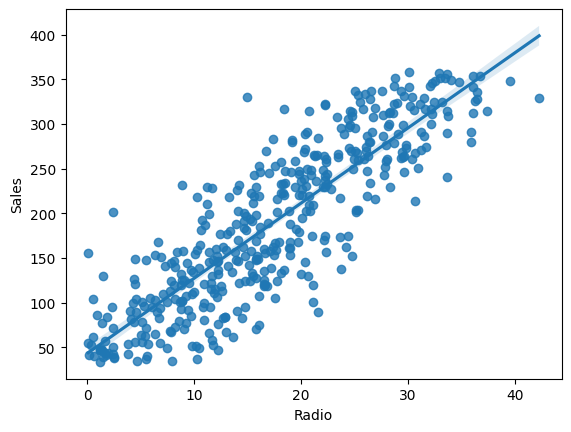

In [60]:
sns.regplot(x = "Radio", y = "Sales", data = train_subset)
plt.show()

In [61]:
'''
Observed Values: These are the actual data points (e.g., actual sales figures).

Predicted Values: These are the values your linear regression model predicts based on the input data (e.g., predicted sales based on radio promotion budget).

So, residuals are simply how much the model's predictions are off from the real data. This applies to both the training data (used to build the model) and the test data (used to evaluate the model).

In the context of the video, after building the model with the training data, you check the residuals to see how well the model is performing. If the residuals are small and randomly distributed, it means your model is making good predictions.

process of creating and evaluating a linear regression model, including how the training and test data sets connect to residuals.
'''

"\nObserved Values: These are the actual data points (e.g., actual sales figures).\n\nPredicted Values: These are the values your linear regression model predicts based on the input data (e.g., predicted sales based on radio promotion budget).\n\nSo, residuals are simply how much the model's predictions are off from the real data. This applies to both the training data (used to build the model) and the test data (used to evaluate the model).\n\nIn the context of the video, after building the model with the training data, you check the residuals to see how well the model is performing. If the residuals are small and randomly distributed, it means your model is making good predictions.\n\nprocess of creating and evaluating a linear regression model, including how the training and test data sets connect to residuals.\n"

In [62]:
residuals = model.resid
residuals

,0
231,-22.024867
268,36.332763
315,54.845684
391,37.653283
179,13.813358
...,...
323,-20.478144
516,-22.510326
248,66.404221
410,31.676262


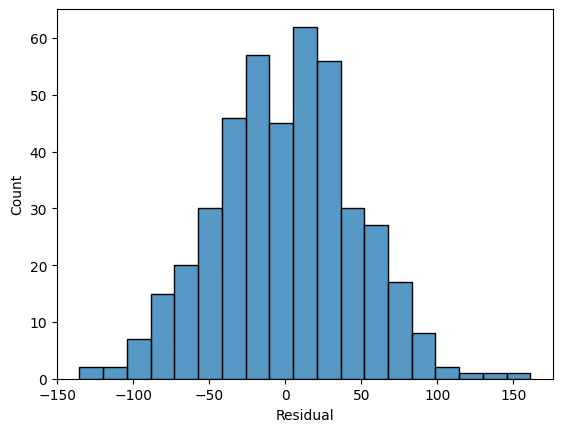

In [63]:
sns.histplot(residuals)
plt.xlabel("Residual")
plt.show()

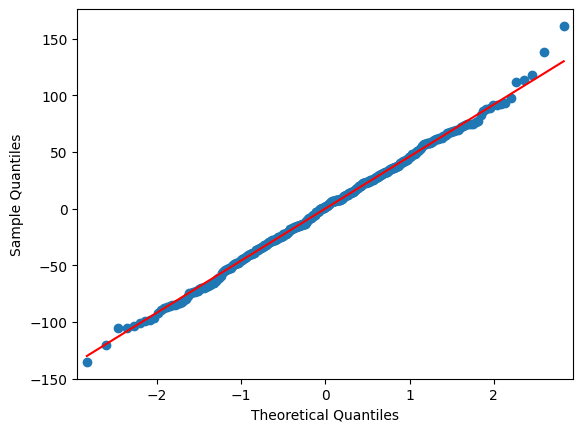

In [64]:
#he QQ plot checks if the residuals follow a normal distribution. Points forming a straight diagonal line indicate normality
sm.qqplot(residuals,line= 's')
plt.show()


In [65]:
#This computes the predicted sales values for the training data based on the 'Radio' promotion budget.


preds_train = model.predict(train_subset["Radio"])

In [66]:
preds_train

,0
231,156.721987
268,195.892921
315,213.720048
391,284.091174
179,167.848243
...,...
323,293.680315
516,350.102828
248,285.125298
410,298.967452


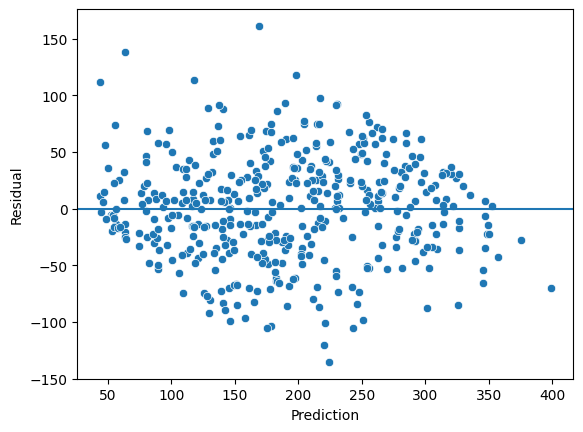

In [67]:
'''
Purpose: This scatter plot shows the residuals (errors) versus the
predicted values (fitted values) for the training data.

Interpretation: The points should resemble a random cloud around the horizontal
line at y=0, indicating that the residuals are randomly distributed


'''
sns.scatterplot(x = preds_train, y = residuals)
plt.axhline(0)
plt.xlabel("Prediction")
plt.ylabel("Residual")
plt.show()

In [68]:
preds_test = model.predict(test_subset["Radio"])

In [69]:
preds_test

,0
0,72.471055
3,212.112667
9,269.397116
11,95.323255
19,150.938780
...,...
544,85.965212
551,128.534124
554,202.556233
559,158.868176


In [70]:
'''
Conclusion
There is a strong statistical relationship between sales and radio advertising budget.
The regression model shows an intercept of 42.86 and a slope of 8.42.
This means that, on average, companies that increase their radio advertising budget by $1 million see an additional $8.42 million in sales.
These findings suggest that radio promotion is an effective driver of sales growth in this dataset.

'''

'\nConclusion\nThere is a strong statistical relationship between sales and radio advertising budget.\nThe regression model shows an intercept of 42.86 and a slope of 8.42.\nThis means that, on average, companies that increase their radio advertising budget by $1 million see an additional $8.42 million in sales.\nThese findings suggest that radio promotion is an effective driver of sales growth in this dataset.\n\n'